## Welcome to Assignment 6!

In this assignment we'll do some more working with regular expressions in context, dig a bit into two of the major libraries for processing language in Python, work on reading files with the CSV module, analyze different eras of poetry, do a bit of plotting, and even build two (somewhat annoying) chatbots!

### 0. Info

#### Name:
\[Adriano Melo Filho]

#### Comments or Questions:
\[...]

#### Completed:
True

### 1. Preparation and Environments

So far in Python we've worked with a few built-in modules: string, random, math, etc. These modules are fundamentally just Python scripts that ship with an installation. For instance, when you do `import string`, you can look at `string.__file__` and it will show you the path to the underlying script. For me it's:

```
/usr/lib/python3.12/string.py
```

It's worth looking at out of curiosity. This is just a python script with useful variables and functions in it, like e.g. the `punctuation` variable.

But there is a ton of useful software for Python that has been written by other people and is available for us to use. The terms *library* or *package* refer to a collection of modules someone else has written but that are not built-in to Python. We can install these external packages and then `import` them to access their functionality.

As you've seen in this class programming is often a process of building up layers of abstraction, using the functionality we've created previously to solve ever-more complex and interesting problems. External libraries are an incredible way to leverage the cleverness and work of many many people beyond ourselves to easily do more complex things.

However, one hiccup is that these packages also can rely upon one another, creating a potentially tangled web of dependencies between different bits of software. On top of that consider that software is often being updated and reworked, and the web gets even more tangled with all the different versions. The core solution to this is a *package manager*, a piece of software that makes sure dependencies are fulfilled and that are no conflicts when a new package is installed. 

Python's built-in package manager is called `pip`, and is often a good solution for installing packages on your home machine. [Documentation here](https://docs.python.org/3/tutorial/venv.html#managing-packages-with-pip). You've likely seen this already in trying to set up Jupyter.

Another commonly used open-source package manager these days for research and scientific computing is [`conda`](https://docs.conda.io/en/latest/) (aka Anaconda), and this is useful to be aware of as well. If you are running your Jupyter install via conda you may need to use this command instead of the one in the code cell below.

```
import sys
!conda install --yes --prefix {sys.prefix} spacy nltk matplotlib
```

But, we'll plan to move forward with `pip`. In the next code cell you'll see a line starting with `!`. This tells Jupyter to run the line as a shell command rather than a Python one. The `!` command below will try using the currently-running version of Python to call `pip`, so that if all goes well the packages we install should be accessible from within this notebook. 

So the packages we'll use (`spacy`, `nltk`, and `matplotlib`) will be installed to the environment, along with lots of other packages that these ones depend on. This step may take a minute as all the requisite packages are installed. If you have trouble with this piece please post on Ed sooner rather than later!

In [33]:
# Installs the necessary packages for the assignment from the currently-running version of python
import sys
!{sys.executable} -m pip install spacy nltk matplotlib

In [34]:
# Run this cell; ye olde run_tests
def run_tests(func, tests):
    print('Running {} tests on the `{}` function...'.format(len(tests), func.__name__))
    errors = 0
    for val, ret in tests:
        try:
            if type(val) == tuple:
                assert func(*val) == ret
            else:
                assert func(val) == ret
        except AssertionError:
            print('\t\terror for input {}'.format(val))
            errors += 1
    if errors == 0:
        print('All tests passed!')

### 2. Incredibly Normal, Usual, Ordinary Expressions



#### a. Write a regular expression called `nametitle_pattern` to match names that have formal titles attached.

For this problem, edit the regular expression below so that when we apply it with `re.match` it will match strings which have at least one name with a formal title attached to it. So these will all be of the form "Title Name" or "Title Name Name" etc.

Specifically, catch these titles: Sir, Dame, Miss, Mister, Madam, Mr., Mrs., Ms., and Dr. 

The period should be optional for titles followed by it (that is, both "Mrs So-and-so" and "Mrs. So-and-so" are okay).

One important thing to note here is that `re.match` is anchored at the beginning of the string, so you have to allow for cases where the title is not the first thing in the string. An alternative would be to match using `re.search`, which is similar but looks anywhere in the string, but we aren't doing that in this problem!

In [35]:
# >>> YOUR ANSWER HERE
nametitle_pattern = r'.*\b(Sir|Dame|Miss|Mister|Madam|Mr|Mrs|Ms|Dr)\.?\s+[A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\b'
# >>> END YOUR ANSWER

In [36]:
import re

tests = [
    ('Along came Sir Galahad', True),
    ('How dare you, Sir. I never!', False),
    ('Sirius Black', False), # notice this shouldn't match even though it is a name
    ('My favorite actress is Dame Judi Dench', True),
    ('Hot Take: Your Argument is Fundamentally Flawed', False),
    ('Oh no, Miss Havisham!', True),
    ('Mississippi River', False),
    ('Mr. Oizo just dropped an epic beat', True),
    ('Mrrr Murmur', False),
    ('Mister Rogers? Love that guy.', True),
    ('Madam Secretary', True), # notice this should match even though it's not a name, need more complex strategies for this one!
    ('Dr Carrie Oakey', True)
]
def test_nametitle(s):
    if re.match(nametitle_pattern, s):
        return True
    else:
        return False
run_tests(test_nametitle, tests)

Running 12 tests on the `test_nametitle` function...
All tests passed!


#### b. Edit your regex from above and complete the function `nametitle_extractor` using regular expression groups to extract names matching the pattern from a string.

Now copy your previous regex to the variable new_nametitle_pattern, and use it in the function below to return a list of the names that appear with titles in a string. The names returned, however, should be just the name as a string without the title.

Check out the `re.findall` or `re.finditer` methods here, which can be looped over to return all matches with a given pattern on a string. You'll need to use groups `()` in your regex to make this work - remember the [associated lesson](https://regexone.com/lesson/nested_groups) from RegexOne and look up `help` on the `match` object, which has a `group` method.

In [37]:
new_nametitle_pattern = r'\b(?:Sir|Dame|Miss|Mister|Madam|Mr|Mrs|Ms|Dr)\.?\s+([A-Z][a-z]+(?:\s+[A-Z][a-z]+)*)'

def nametitle_extractor(s):
    matches = []
    # >>> YOUR ANSWER HERE
    for m in re.finditer(new_nametitle_pattern, s):
        matches.append(m.group(1))
    # >>> END YOUR ANSWER
    return matches
    

In [38]:
tests = [
    ('Along came Sir Galahad, who exclaimed, "Oh no, Miss Havisham!"', ['Galahad', 'Havisham']),
    ("Mr. Rogers' favorite actress is Dame Judi Dench", ['Rogers','Judi Dench']),
    ('Mr. Oizo just dropped an epic beat', ['Oizo']),
    ('Welcome to Singalongs with Dr Carrie Oakey', ['Carrie Oakey']),
    ('Just a ho-hum magical day with my friend Sirius Black.', []),    
]
run_tests(nametitle_extractor, tests)

Running 5 tests on the `nametitle_extractor` function...
All tests passed!


### 3. Borrowing Privileges at the NLP Libraries

There are a number of good libraries for processing language data in Python, here we'll play with two: [NLTK](https://www.nltk.org/) and [spaCy](https://spacy.io/).

NLTK is older and in some sense more established, with a greater focus on traditional approaches; spaCy is newer and more modern with a focus on the latest-and-greatest applications.

Both need us to start by downloading some data and models. This will download pre-trained machine learning models that allow us to do some neat linguistic processing without much of a hassle.

In [39]:
import nltk
nltk.download('punkt') # word tokenizer model
nltk.download('averaged_perceptron_tagger') # part-of-speech tagger
nltk.download('brown') # the Brown corpus: https://en.wikipedia.org/wiki/Brown_Corpus

import spacy
if spacy.util.is_package('en_core_web_sm'): 
    print('spaCy model already installed.')
else:
    !{sys.executable} -m spacy download en_core_web_sm

spaCy model already installed.


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adrianomelofilho/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/adrianomelofilho/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package brown to
[nltk_data]     /Users/adrianomelofilho/nltk_data...
[nltk_data]   Package brown is already up-to-date!


#### a. Complete the functions `nltk_tokenized` and `spacy_tokenized` to compare each library's tokenization algorithm.

In [40]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser','ner'])

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/adrianomelofilho/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/adrianomelofilho/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


The above code loads NLTK's word_tokenize function, and the spaCy NLP pipeline in an object named `nlp`. In the spaCy case, we explicitly disable the syntactic parser and named entity recognizer since they slow things down a bit and we won't use them in this assignment.

Play with both of these (or look them up with `help`) to figure out how to use them to tokenize a string. They are also discussed in [Chapter 3](https://www.nltk.org/book/ch03.html) of the NLTK book and in the [spaCy documentation](https://spacy.io/usage/linguistic-features).

In the below functions, you want to return a string representation of the sentence where each token is separated by space. For instance, `"Don't do that!"` should return `"Do n't do that !"`

In [41]:
def nltk_tokenized(s):
    # >>> YOUR ANSWER HERE
    return ' '.join(word_tokenize(s))
    # >>> END YOUR ANSWER

def spacy_tokenized(s):
    # >>> YOUR ANSWER HERE
    doc = nlp(s)
    return ' '.join([token.text for token in doc])
    # >>> END YOUR ANSWER

In [42]:
tests = [
    '"Can you see the snow-capped mountains?" asked Martha. "I can\'t," replied Xavier.',
    "Get me those T.P.S. reports A.S.A.P., Mr. O'Donohue!",
    "After today, I'll never call you a ne'er-do-well again.",
    "What's the frequency, Kenneth?"
]
s = "What's the frequency, Kenneth?"
try:
    assert nltk_tokenized(s) == spacy_tokenized(s) == "What 's the frequency , Kenneth ?"
    print("The tokenizations look good!")
except AssertionError:
    print("The tokenizations don't appear to be working yet.")

    
print("\nTokenization outputs:")
for test in tests:
    print('-------')
    print('Raw:\t', test)
    print('NLTK:\t', nltk_tokenized(test))
    print('spaCy:\t', spacy_tokenized(test))

The tokenizations look good!

Tokenization outputs:
-------
Raw:	 "Can you see the snow-capped mountains?" asked Martha. "I can't," replied Xavier.
NLTK:	 `` Can you see the snow-capped mountains ? '' asked Martha . `` I ca n't , '' replied Xavier .
spaCy:	 " Can you see the snow - capped mountains ? " asked Martha . " I ca n't , " replied Xavier .
-------
Raw:	 Get me those T.P.S. reports A.S.A.P., Mr. O'Donohue!
NLTK:	 Get me those T.P.S . reports A.S.A.P. , Mr. O'Donohue !
spaCy:	 Get me those T.P.S. reports A.S.A.P. , Mr. O'Donohue !
-------
Raw:	 After today, I'll never call you a ne'er-do-well again.
NLTK:	 After today , I 'll never call you a ne'er-do-well again .
spaCy:	 After today , I 'll never call you a ne'er - do - well again .
-------
Raw:	 What's the frequency, Kenneth?
NLTK:	 What 's the frequency , Kenneth ?
spaCy:	 What 's the frequency , Kenneth ?


#### b. What do you gather in terms of differences and similarities between NLTK and spaCy's tokenization?

NLTK and spaCy mostly produce the same tokens from these examples. Both split punctuation into separate tokens and break contractions like “What’s” into “What” and “’s.” The main difference is that spaCy is faster and part of a larger NLP pipeline. NLTK just uses more traditional rule based tokenizers.

#### c. Complete the functions `nltk_stemmed` and `spacy_lemmatized` to convert strings to stem- and lemma-only versions.

We talked a bit in class about lemmatization, a form of morphological analysis that allows us to group together all the inflected forms of a word as the same canonical type. E.g. `run`, `running`, `ran` all become simply `run`.

An earlier set of algorithms called *stemming* were aimed at doing a similar thing. They used heuristics to chop off morphological markings to make inflected words map to the same string representation. spaCy doesn't have stemming, but NLTK does. Below use the classic PorterStemmer to return a space-separated stem-only version of a string. Some helpful details in the [NLTK book](https://www.nltk.org/book/ch03.html#sec-normalizing-text).

On the other hand, lemmatization is not super well-implemented in NLTK and is a bit of a pain to do, so let's just do it in spaCy. In the below function return a space-separated string of lemmas. Check the available properties on spaCy's `token` objects, and note that in spacy you often need to return attributes ending in an underscore. Again the [spaCy documentation](https://spacy.io/usage/linguistic-features) is very helpful.

In [43]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def nltk_stemmed(s):
    # >>> YOUR ANSWER HERE
    tokens = word_tokenize(s)
    stems = []
    for t in tokens:
        if t == 'I':
            stems.append('I')
        else:
            stems.append(stemmer.stem(t))
    return ' '.join(stems)
    # >>> END YOUR ANSWER

def spacy_lemmatized(s):
    # >>> YOUR ANSWER HERE
    doc = nlp(s)
    return ' '.join([token.lemma_ for token in doc])
    # >>> END YOUR ANSWER

In [44]:
tests = [
    'I was supposing that things would be most excellent.',
    'That guy had gone before, was going regularly, is still going, and will go again.',
    'Peter Piper picked a peck of pickled peppers. A peck of pickled peppers Peter Piper picked.',
    'Three thin thinkers thinking thick thoughtful thoughts.',
    'The running man ran down the runway he had run before.'
]
s = 'I was supposing that things would be most excellent.'
try:
    assert nltk_stemmed(s) == 'I wa suppos that thing would be most excel .'
    assert spacy_lemmatized(s) == 'I be suppose that thing would be most excellent .'
    print("The lemmatizations look good!")
except AssertionError:
    print("The lemmatizations don't appear to be working yet.")

print("\nStemming and Lemmatization outputs:")
for test in tests:
    print('-------')
    print('Raw:\t', test)
    print('NLTK stem:\t', nltk_stemmed(test))
    print('spaCy lemma:\t', spacy_lemmatized(test))

The lemmatizations look good!

Stemming and Lemmatization outputs:
-------
Raw:	 I was supposing that things would be most excellent.
NLTK stem:	 I wa suppos that thing would be most excel .
spaCy lemma:	 I be suppose that thing would be most excellent .
-------
Raw:	 That guy had gone before, was going regularly, is still going, and will go again.
NLTK stem:	 that guy had gone befor , wa go regularli , is still go , and will go again .
spaCy lemma:	 that guy have go before , be go regularly , be still go , and will go again .
-------
Raw:	 Peter Piper picked a peck of pickled peppers. A peck of pickled peppers Peter Piper picked.
NLTK stem:	 peter piper pick a peck of pickl pepper . a peck of pickl pepper peter piper pick .
spaCy lemma:	 Peter Piper pick a peck of pickle pepper . a peck of pickle pepper Peter Piper pick .
-------
Raw:	 Three thin thinkers thinking thick thoughtful thoughts.
NLTK stem:	 three thin thinker think thick thought thought .
spaCy lemma:	 three thin thinker t

#### d. What do you notice about these outputs? Is lemmatization always better than stemming? Do we always want to do some form of text normalization (whether stemming or lemmatization)? Why or why not?

The stemmed versions chop words down pretty aggressively and sometimes produce weird forms like “suppos” or “befor,”. The lemmatized versions keep real words like “suppose” and “before.”

Lemmatization is usually cleaner and more accurate, but it’s also slower and not always necessary. Depending on the problem we might not want to normalize everything because things like tense or word form could actually matter.

#### e. Complete the function `pos_tagged` to annotate strings with their part-of-speech tags.

Now let's use the functionality of both packages to identify part-of-speech tags in text.

The [reading](https://robvoigt.net/lin127/slides/slp_extracts.pdf) for this week explained part-of-speech tagging as a task, namely to identify the syntactic category of words. There are many possible tag sets we could use, but both NLTK and spaCy default to outputting Penn Treebank-style tags. These are also discussed in the reading, with a helpful table listing the tags on the second-to-last-page in Figure 8.1. 

A common format for representing POS tags is `word_tag`, so we'll use that here. Take in a string, tokenize it, and return a space-separated string where each token is followed by an underscore and its POS tag.

So an example output should look like:
```
I_PRP was_VBD supposing_VBG that_IN things_NNS would_MD be_VB most_RBS excellent_JJ ._.
```

In [45]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

def nltk_pos_tagged(s):
    # >>> YOUR ANSWER HERE
    tokens = word_tokenize(s)
    tagged = nltk.pos_tag(tokens)
    return ' '.join([f"{word}_{tag}" for word, tag in tagged])
    # >>> END YOUR ANSWER

def spacy_pos_tagged(s):
    # >>> YOUR ANSWER HERE
    doc = nlp(s)
    return ' '.join([f"{token.text}_{token.tag_}" for token in doc])
    # >>> END YOUR ANSWER

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/adrianomelofilho/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [46]:
tests = [
    'I was supposing that things would be most excellent.',
    'That guy had gone before, was going regularly, is still going, and will go again.',
    'Peter Piper picked a peck of pickled peppers. A peck of pickled peppers Peter Piper picked.',
    'Three thin thinkers thinking thick thoughtful thoughts.',
    'Colorless green ideas sleep furiously.'
]
s = 'I was supposing that things would be most excellent.'
try:
    assert nltk_pos_tagged(s) == spacy_pos_tagged(s) == 'I_PRP was_VBD supposing_VBG that_IN things_NNS would_MD be_VB most_RBS excellent_JJ ._.'
    print("The POS tagging looks good!")
except AssertionError:
    print("The POS tagging doesn't appear to be working yet.")
print("\nPOS tagging outputs:")
for test in tests:
    print('-------')
    print('Raw:\t', test)
    print('NLTK:\t', nltk_pos_tagged(test))
    print('spaCy:\t', spacy_pos_tagged(test))

The POS tagging looks good!

POS tagging outputs:
-------
Raw:	 I was supposing that things would be most excellent.
NLTK:	 I_PRP was_VBD supposing_VBG that_IN things_NNS would_MD be_VB most_RBS excellent_JJ ._.
spaCy:	 I_PRP was_VBD supposing_VBG that_IN things_NNS would_MD be_VB most_RBS excellent_JJ ._.
-------
Raw:	 That guy had gone before, was going regularly, is still going, and will go again.
NLTK:	 That_DT guy_NN had_VBD gone_VBN before_RB ,_, was_VBD going_VBG regularly_RB ,_, is_VBZ still_RB going_VBG ,_, and_CC will_MD go_VB again_RB ._.
spaCy:	 That_DT guy_NN had_VBD gone_VBN before_RB ,_, was_VBD going_VBG regularly_RB ,_, is_VBZ still_RB going_VBG ,_, and_CC will_MD go_VB again_RB ._.
-------
Raw:	 Peter Piper picked a peck of pickled peppers. A peck of pickled peppers Peter Piper picked.
NLTK:	 Peter_NNP Piper_NNP picked_VBD a_DT peck_NN of_IN pickled_JJ peppers_NNS ._. A_DT peck_NN of_IN pickled_JJ peppers_NNS Peter_NNP Piper_NNP picked_VBD ._.
spaCy:	 Peter_NNP Piper_

#### f. What do you notice about these outputs? How do NLTK and spaCy compare in terms of POS tagging?

The POS tags from NLTK and spaCy are mostly the same across these examples so they agree on most of the grammatical categories. There's a few small differences like how spaCy tags “pickled” as VBN while NLTK tags it as JJ or how they treat “Colorless.” They mostly behave similarly, but each model sometimes interprets a word’s role in the sentence a little differently.

#### g. Complete the function `calculate_left_adjectives` to count the adjectives occurring to the left of any given word in the Brown Corpus.

The [Brown Corpus](https://en.wikipedia.org/wiki/Brown_Corpus) is a famous classic corpus (language dataset) comprised of texts from 1961. The corpus itself was collected throughout the 1960s, contains a number of genres, and was the first computerized corpus to exceed one million words in size.

Now that we know how to tokenize and lemmatize and POS-tag, we can start to ask some useful questions of corpora like this. The function below takes a genre/category from the Brown corpus and a 'target word' for which we would like to examine the adjectives, and returns a `Counter` with counts of adjectives (i.e. words tagged 'JJ') occuring to the left of the target word. So if the target word is 'cat', an instance of 'smelly cat' in the corpus gets `adj_counts['smelly'] += 1`.

NLTK has an interface for loading the Brown corpus, so that is done for you into a variable called 'sentences' which is a list of lists of words. Feel free to use either NLTK or spaCy to do this problem.

In [47]:
from nltk.corpus import brown
from collections import Counter

def calculate_left_adjectives(brown_category, target_word):
    sentences = brown.sents(categories=brown_category)
    
    adj_counts = Counter()
    # >>> YOUR ANSWER HERE
    target_word = target_word.lower()

    for sentence in sentences:
        tagged = nltk.pos_tag(sentence)

        for i in range(1, len(tagged)):
            word, tag = tagged[i]
            prev_word, prev_tag = tagged[i - 1]

            if word.lower() == target_word:
                if prev_tag == 'JJ':
                    adj_counts[prev_word.lower()] += 1
    # >>> END YOUR ANSWER
    return adj_counts

# Feel free to play around with the 'category' and 'target_word' variables here to see what results you get!
#
# The possible brown corpus categories are news, editorial, reviews, religion, hobbies, lore, belles_lettres, 
# government, learned, fiction, mystery, science_fiction, adventure, romance, and humor.
category = 'fiction'
target_word = 'hair'
adjectives = calculate_left_adjectives(category, target_word)
print("Top adjectives to the left of {} in {}:".format(target_word.upper(), category.upper()))
for item in adjectives.most_common(10):
    print('\t',item[1], '\t', item[0])
# for fiction/hair, results should be gray, black, grizzled, etc...

Top adjectives to the left of HAIR in FICTION:
	 2 	 gray
	 2 	 black
	 1 	 grizzled
	 1 	 silky
	 1 	 sorrel
	 1 	 own
	 1 	 reddish
	 1 	 red
	 1 	 sandy
	 1 	 brown


### 4. Manatee, Jubilee, Potpourri, CSV

CSV stands for "comma-separated values," a common file format for reading and writing data. It generally has a first row of "headers" which identify what sort of data will be in each column, and then the following rows contain the data entries. E.g.:

```
robot,height,weight
R2D2,3'6",70.5lbs
BB-8,2'2",92.5lbs
C-3PO,5'9",165.3lbs
```

Python has an incredibly useful built-in module - the CSV module - for working with this sort of file, and it does a lot of nice clean-up behind the scenes for you. The basic paradigm is to create a 'reader' object, which then can be iterated over to get the rows of a file. Check out [the documentation](https://docs.python.org/3/library/csv.html) and associated examples to do the following problems. 

Specifically, I strongly suggest you use the [DictReader class](https://docs.python.org/3/library/csv.html#csv.DictReader), which when iterated over produces a series of dictionaries where the keys are the headers and the values are the associated data entires. So in the example above, iterating with a DictReader we would get a sequence of dictionaries like:
```
{'robot':'R2D2', 'height': '3\'6"', 'weight': '70.5lbs'}
{'robot':'BB-8', 'height': '2\'2"', 'weight': '92.5lbs'}
{'robot':'C-3PO', 'height': '5\'9"', 'weight': '165.3lbs'}
```

In this section we'll use the CSV module to read some neat linguistic lexicons into usable formats for our purposes.

#### a. Complete the function `read_concreteness` to load the Brysbaert et al. (2014) concreteness ratings into a dictionary.

Brysbaert, Warriner, and Kuperman (2014) have a neat paper entitled [Concreteness ratings for 40 thousand generally known English word lemmas](https://link.springer.com/article/10.3758/s13428-013-0403-5), in which as the title suggests they obtain estimates on a scale from 1 to 5 of how concrete (as opposed to abstract) 40,000 word lemmas are. So for instance *lizard* is quite concrete (rated 4.68) because it can walk around and lick things; *affability* (rated 1.54) is a bit harder to hold in the palm of your hand; and *dermatology* (rated 2.92) is somewhere in between.

These ratings (obtained from their website [here](http://crr.ugent.be/archives/1330)) are in the file `brysbaert_concreteness.csv` in your assignment zip. Check out the file to get a sense for the format. We want to read this file into a dictionary mapping words to concreteness ratings. The key fields to notice are the 'Lemma' field, containing the relevant lemma, and 'Conc.M', containing the mean rating from their annotators.

Note that the CSV module will read all fields as strings by default, so we want to cast the values to float to use them later.

In [48]:
import csv

def read_concreteness(f='brysbaert_concreteness.csv'):
    concreteness = {}
    # >>> YOUR ANSWER HERE
    with open(f, newline='', encoding='utf-8') as infile:
        reader = csv.DictReader(infile)
        for row in reader:
            concreteness[row['Lemma']] = float(row['Conc.M'])
    # >>> END YOUR ANSWER
    return concreteness

In [49]:
concreteness = read_concreteness()

error = False
if not len(concreteness) == 39954:
    print("Error, expected 39954 entries but found {}".format(len(concreteness)))
    error = True
    
tests = [
    ('sudsy', 4.48),
    ('deteriorating', 3.38),
    ('sour', 3.14),
    ('picturesque', 2.76),
    ('mysterious', 1.96)
]
def test_concreteness(w):
    return concreteness[w]
run_tests(test_concreteness, tests)

Running 5 tests on the `test_concreteness` function...
All tests passed!


#### b. Complete the function `read_emotion_intensity` to load the Mohammed (2018) emotion intensity ratings into a nested dictionary.

Another cool lexicon-building project is Saif Mohammed (2018)'s  [NRC Emotion Intensity Lexicon](https://saifmohammad.com/WebPages/AffectIntensity.htm). This lexicon aims to capture the type of emotion from eight basic emotion classes associated with particular words, as well as their intensity on a scale of 0-1. So for instance *disgruntled* is associated with 'anger' and 'sadness' at a level around 0.7, and with 'disgust' to a lesser degree of 0.4. 

Again this file is included in your assignment zip as `nrc_emotion_intensity.txt`. Check out the formatting of this file. You'll note that it looks kind of like a CSV, with headers and rows of values, but it has no commas! That's okay, the CSV module is still to the rescue. CSV classes like DictReader can take a 'delimiter' argument, which specifies what the delimiter should be if not a comma. In this case it's a tab character, or `'\t'`. Specify this as the delimiter and everything else will work the same!

Note that since this data representation has two levels (the word, and the various emotions), we need to build a nested dictionary. Specifically, we want a dictionary of emotions nested within words. So `emotion_intensity['disgruntled']['sadness']` should return `0.712` as a float, and `emotion_intensity['disgruntled']['disgust']` should return `0.406`.

You can do this by manually defining the interior dictionary as need arises (e.g., `emotion_intensity[word] = {}`), or by using a defaultdict(dict).

In [50]:
def read_emotion_intensity(f="nrc_emotion_intensity.txt"):
    emotion_intensity = {}
    # >>> YOUR ANSWER HERE
    with open(f, newline='', encoding='utf-8') as infile:
        reader = csv.DictReader(infile, delimiter='\t')

        for row in reader:
            word = row['word']
            emotion = row['emotion']
            score = float(row['emotion-intensity-score'])

            if word not in emotion_intensity:
                emotion_intensity[word] = {}

            emotion_intensity[word][emotion] = score
    # >>> END YOUR ANSWER
    return emotion_intensity

In [51]:
emotion_intensity = read_emotion_intensity()

error = False
if not len(emotion_intensity) == 5975:
    print("Error, expected 5975 entries but found {}".format(len(concreteness)))
    error = True
    
tests = [
    (('outrageous', 'surprise'), 0.750),
    (('magnificent', 'joy'), 0.859),
    (('magnificent', 'anticipation'), 0.531),
    (('ridiculous', 'disgust'), 0.352),
    (('awful', 'sadness'), 0.641),
    (('insight', 'trust'), 0.562)
]
def test_emotion_intensity(word, emotion):
    return emotion_intensity[word][emotion]
run_tests(test_emotion_intensity, tests)


Running 6 tests on the `test_emotion_intensity` function...
All tests passed!


### 5. Writ in Stone

#### a. Calculate which poems are more concrete by era and topic.

`poetry.csv` in your assignment zip is a file from [here](https://www.kaggle.com/ultrajack/modern-renaissance-poetry) on Kaggle, a website for machine learning competitions. It is a CSV of some poems from www.poetryfoundation.org/ with two interesting associated tags: one for the 'era' the poem was written in (Renaissance or Modern) and another for its 'topic' (Nature, Love, or Mythology & Folklore). I recommend opening the file (in `less` or otherwise) and giving it a look to understand its format and fields before you get started here.

Inspired by [Kao and Jurafsky (2012)](https://www.aclweb.org/anthology/W12-2502.pdf), who found that professional poets tend to write more concretely than amateur poets, let's compare these categories on the basis of their concreteness. 

To do this, use a DictReader to loop over the poetry CSV. In each loop, create a key by combining the 'era' and 'topic' fields in the row (for instance, `key = era + '_' + topic`). Use spaCy to loop over each token and get the concreteness of its lemma (skipping the word if the lemma is not in the concreteness dict). Append the concreteness to the list in the counts dictionary for the current key. 

In the end we should have a `counts` dictionary with six keys (two eras times three topics), each of which has as its value a long list of concreteness values. I've provided code below your section using the [`statistics`](https://docs.python.org/3/library/statistics.html) module to calculate and print the mean value for each era/topic.

In [52]:
from collections import defaultdict

counts = defaultdict(list)

# >>> YOUR ANSWER HERE
with open('poetry.csv', newline='', encoding='utf-8') as infile:
    reader = csv.DictReader(infile)

    for row in reader:
        key = row['era'] + '_' + row['topic']
        doc = nlp(row['content'])

        for token in doc:
            lemma = token.lemma_.lower()
            if lemma in concreteness:
                counts[key].append(concreteness[lemma])
# >>> END YOUR ANSWER

import statistics
for category in counts:
    print(round(statistics.mean(counts[category]), 3), '\t', category)
# for reference, Renaissance_Love should be close to 2.597

2.581 	 Renaissance_Mythology & Folklore
2.601 	 Renaissance_Nature
2.566 	 Renaissance_Love
2.73 	 Modern_Mythology & Folklore
2.805 	 Modern_Nature
2.759 	 Modern_Love


#### b. Plot the results of the above.

It's very common in programming to use code from others and adapt it to your needs. This is a great thing to do, and a great way to learn, but of course cite your sources! Often a good method is to do this in a comment, e.g. `# modified from so-and-so at xyz url`.

Anyway, we'll do this here as a way to check out matplotlib. Matplotlib is a very powerful plotting library for Python, which we don't have time to do a deep dive on, but you can get your feet wet very quickly.

Start by copying the code for the Horizontal Bar Chart example from Ben Alex Keen here:
https://benalexkeen.com/bar-charts-in-matplotlib/

Figure out what the variables mean, and change them to what they should be in our case. You can earlier type this out manually or do it programmatically. Be sure to change all the labels too!

You can simply remove the `xerr` argument to `plt.barh`, but for an extra challenge, calculate and plot the 95% confidence intervals on the chart. The formula for the 95% confidence interval is:
\\[ 95\% CI err = 1.96 * \frac{\sigma}{\sqrt{N}} \\] 

Where \\(\sigma\\) is the standard deviation of the values (`statistics.stdev`) and \\(\sqrt{N}\\) is the square root of the number of observations (`math.sqrt` on the number of values in a category).

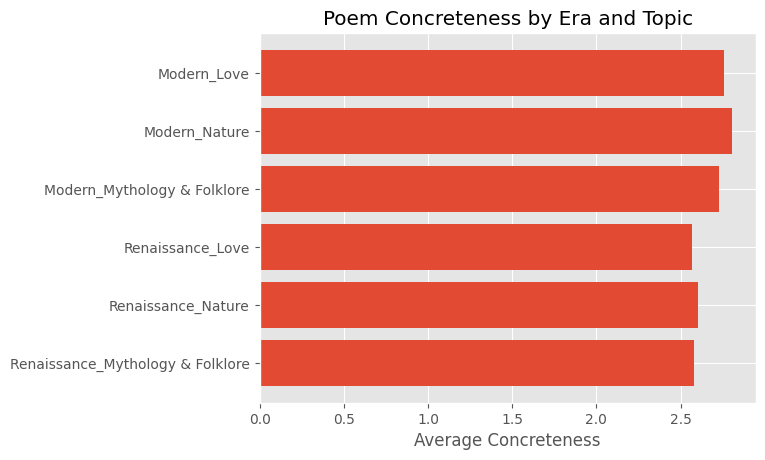

In [53]:
import statistics, math
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

# >>> YOUR ANSWER HERE
labels = []
means = []

for category in counts:
    labels.append(category)
    means.append(statistics.mean(counts[category]))

y_pos = range(len(labels))

plt.barh(y_pos, means)
plt.yticks(y_pos, labels)
plt.xlabel("Average Concreteness")
plt.title("Poem Concreteness by Era and Topic")

plt.show()
# >>> END YOUR ANSWER

#### c. Qualitatively, what have we learned from this? How do Renaissance and Modern poetry compare in terms of lexical concreteness? Do genre differences play a role?

Modern poems generally have higher average concreteness scores than Renaissance poems across all three topics suggesgting modern poetry tends to use slightly more concrete language.

Genre also matters; Nature poems are the most concrete in both eras while Love and Mythology/Folklore are a little less concrete.

### 6. Gettin' Chatty

Congrats on making it this far! These last problems are quite open ended, so don't waste your whole life on them (because you could definitely do that), but do try to give them a stab.

In the reading for this week you heard about ELIZA, a classic computer program that used regular expressions to sound like a Rogerian therapist by reflecting back the thoughts of the user interacting with it.

Here we'll follow that approach with two little bots meant to incorporate some of the strategies we've been working on to create some sort of semi-reasonable conversation.

First we'll define some regular expression replacements that will be used in both cases to cascade over the user's input and replace pronouns with flipped equivalents (e.g. "I" \\(\rightarrow\\) "you") for responses.

In [54]:
pronoun_replacements = [(r'\b([Tt]hey|[Ww]e)\'re\b', r'\1 are'),
                        (r'\b[Ii]t\'s\b', r'it is'),
                        (r'\b[Tt]hat\'s\b', r'that is'),
                        (r'\b[Ii] am\b', 'you are'),
                        (r'\b[Ii]\'m\b', 'you are'),
                        (r'\b([Ii]|me)\b', 'you'),
                        (r'\b[Mm]y\b', 'your'),
                        (r'\b[Mm]ine\b', 'yours')]

#### a. Complete the function `existential_why_bot` to help our bot communicate its semi-infinite curiosity in better English.

This bot is like an annoying kid who just learned how to ask WHY. But hey, maybe it will help you reflect more deeply on the purpose of your life, who knows. 

The main structure is set up for you and it currently 'works', but the task here is to use a few facts about the structure of questions in English to write a series of `re.sub` statements that alter the response to be more jarringly grammatically correct. Try it out and play with it (response 'q' to quit), think about how the answers could seem more natural.

I suggest trying to implement, roughly in order:
- Remove 'because', 'so', and 'so that' from the beginning of the response
- Convert some modals like 'might', 'may', 'could', and 'can' to be 'should' instead (e.g. Q: Why? A: so I can be free Q: But why should you be free?)
- Remove the 'to' from infinitives when they start the response (e.g. Q: Why? A: to be better. Q: But why be better?)
- Implement very simple [subject-auxiliary inversion](https://en.wikipedia.org/wiki/Subject%E2%80%93auxiliary_inversion), e.g. the first time any of `(must|will|would|won\'t|did|didn\'t|haven\'t|do|don\'t|is|am|are|should)` appears after some material in the response, move it to be ahead of that material (e.g. Q: Why? A: it is time. Q: But why is it time?
- If we didn't have an infinitive or an inversion, add [do-support](https://en.wikipedia.org/wiki/Do-support) by inserting a 'do' at the beginning of the response

You'll notice that ordering of the cascade of substitutions definitely matters.

Extra and significantly more complicated problems:
- Improve 'do-support' to sometimes be 'does' for third person 
- Deal with embedded clauses (e.g. using 'that') as appropriately as possible
- Resolve tense differences using e.g. https://spacy.io/universe/project/lemminflect

In [55]:
import random, string

def existential_why_bot():
    response = input("Tell me something about yourself.\n\t")
    
    while True:
        if '?' in response or 'you' in response or response == 'q': 
            print("This isn't about me and I won't be taking questions - direct any inquiries to my staff. Good day.")
            return
        
        response = response.strip().strip(string.punctuation)
        for pattern, repl in pronoun_replacements:
            response = re.sub(pattern, repl, response)
        
        if random.random() > .9: # with some probability call it quits.
            break

        response = response # create a new variable called 'response' for continued processing
        
        # >>> BEGIN YOUR ANSWER
        # remove "because", "so", "so that" at the start
        response = re.sub(r'^(because|so|so that)\s+', '', response, flags=re.I)

        # convert modals to "should"
        response = re.sub(r'\b(might|may|could|can)\b', 'should', response)

        # remove "to" if the sentence starts with an infinitive
        response = re.sub(r'^to\s+', '', response, flags=re.I)

        # subject, aux inversion
        response = re.sub(r'(.+?)\s+(is|are|am|was|were|will|would|did|do|does|should|have|has)\b', r'\2 \1', response, count=1)

        # if nothing inverted, add do-support
        if not re.match(r'^(is|are|am|was|were|will|would|did|do|does|should|have|has)\b', response):
            response = "do " + response

        # >>> END YOUR ANSWER 
        question = "But why {}?\n\t".format(response)
        response = input(question)
        
    print('Aha, I see, {}. It all makes sense now. Thanks, bye.'.format(response))


In [56]:
existential_why_bot()

Aha, I see, the spices make it taste good. It all makes sense now. Thanks, bye.


#### b. Complete the function `overly_specific_empathy_bot`, which wants to hear how you feel but only if your feelings are stated using many concrete words.

This bot is similar to the above but a little more emotional and a little more canned. It will keep asking you how you feel until you answer with a sufficient amount of sufficiently concrete words. 

Your task is to add up the emotional associations of all the words used in the final response to tell the bot how it should feel about all that concrete stuff you said.

So tokenize the response, find which words occur in our emotion dictionary, and for each emotion category sum up the intensity values. Set `top_emotion` to the emotion category with the highest intensity score, and all will be well.

There's an infinite variety of ways you could improve this bot as well. One possibility is that the bot could take into account low values in a category - for instance, *picnic* and *spa* are listed as associated with surprise, but with very low values, so we don't have to necessarily react with surprise to the presence of these.

In [57]:
bot_replies = {'sadness': "I'm sorry that {}...",
               'disgust': "Ugh, that sounds gross that {}.",
               'anger': "I hear you that you're angry because {}.",
               'joy': "That's so great that {}!",
               'anticipation': "How exciting that {}!",
               'fear': "Yikes, it sounds scary that {}.",
               'surprise': "Wow, it sounds surprising that {}!!",
               'trust': "Very good to hear that {}.",
               'other': "I'm not sure I get you."}


def overly_specific_empathy_bot():
    response = input("How do you feel?\n\t")    
    
    CONCRETENESS_THRESHOLD = 3.0
    MIN_CONCRETE_WORDS = 3
    idx = 0
    while True:
        idx += 1
        doc = nlp(response.lower())
        concrete_words = [token.lemma_ for token in doc if concreteness.get(token.lemma_, 0.0) > CONCRETENESS_THRESHOLD]
        if response == 'q':
            return
        elif len(concrete_words) <= MIN_CONCRETE_WORDS:
            response = input("Can you be more specific? How do you *{}* feel?\n\t".format(' '.join(['really']*idx)))
        else:
            break
    
    response = response.strip().strip(string.punctuation)
    for pattern, repl in pronoun_replacements:
        response = re.sub(pattern, repl, response)
    # make sure the response starts with 'you feel'
    if not re.match('^you feel (.+)', response):
        response = 'you feel ' + response
    
    # >>> YOUR ANSWER HERE
    # collect emotion scores
    emotion_scores = defaultdict(float)
    doc = nlp(response)

    for token in doc:
        lemma = token.lemma_
        if lemma in emotion_intensity:
            for emotion, score in emotion_intensity[lemma].items():
                emotion_scores[emotion] += score
    
    # figure out which had the highest score
    # specifically your job is to change the 'top_emotion' string to the appropriate key 
    # in 'bot_replies' based on the emotion words used
    top_emotion = 'other' 
    if emotion_scores:
        top_emotion = max(emotion_scores, key=emotion_scores.get)
    
    # >>> END YOUR ANSWER
    
    print(bot_replies[top_emotion].format(response))
    
    
    

In [58]:
overly_specific_empathy_bot()

That's so great that you feel happy walking on the warm sand and hearing the ocean waves!
